In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, ExtraTreesClassifier
from sklearn.svm import SVC
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
from sklearn.model_selection import cross_val_score, GridSearchCV, RandomizedSearchCV

import joblib
import warnings


warnings.filterwarnings('ignore')

In [ ]:
DATASET_NAME = 'IRIS.csv'
df = pd.read_csv(DATASET_NAME)
print(f"Successfully loaded the dataset: {DATASET_NAME}")

Successfully loaded the dataset: IRIS.csv


In [ ]:
display(df.head())

,sepal_length,sepal_width,petal_length,petal_width,species
0,5.1,3.5,1.4,0.2,Iris-setosa
1,4.9,3.0,1.4,0.2,Iris-setosa
2,4.7,3.2,1.3,0.2,Iris-setosa
3,4.6,3.1,1.5,0.2,Iris-setosa
4,5.0,3.6,1.4,0.2,Iris-setosa


In [ ]:
display(df.tail())

,sepal_length,sepal_width,petal_length,petal_width,species
145,6.7,3.0,5.2,2.3,Iris-virginica
146,6.3,2.5,5.0,1.9,Iris-virginica
147,6.5,3.0,5.2,2.0,Iris-virginica
148,6.2,3.4,5.4,2.3,Iris-virginica
149,5.9,3.0,5.1,1.8,Iris-virginica


In [ ]:
print(f"Shape of the dataset (rows, columns): {df.shape}")

Shape of the dataset (rows, columns): (150, 5)


In [ ]:
print("Column names:")
for col in df.columns:
    print(f"- {col}")

Column names:
- sepal_length
- sepal_width
- petal_length
- petal_width
- species


In [ ]:
print("Data types of each column:")
display(df.info())

Data types of each column:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 150 entries, 0 to 149
Data columns (total 5 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   sepal_length  150 non-null    float64
 1   sepal_width   150 non-null    float64
 2   petal_length  150 non-null    float64
 3   petal_width   150 non-null    float64
 4   species       150 non-null    object 
dtypes: float64(4), object(1)
memory usage: 6.0+ KB


None

In [ ]:
# The last column 'species' is the target variable, so we exclude it from the feature count.
num_features = df.shape[1] - 1
print(f"Number of features (excluding the target variable): {num_features}")

Number of features (excluding the target variable): 4


In [ ]:
target_variable = 'species'
print(f"Target variable: {target_variable}")

print("Unique classes in the target variable:")
display(df[target_variable].unique())

Target variable: species
Unique classes in the target variable:


array(['Iris-setosa', 'Iris-versicolor', 'Iris-virginica'], dtype=object)

In [ ]:
numerical_cols = df.select_dtypes(include=np.number).columns.tolist()
print(f"Numerical columns: {numerical_cols}")

Numerical columns: ['sepal_length', 'sepal_width', 'petal_length', 'petal_width']


In [ ]:
categorical_cols = df.select_dtypes(include='object').columns.tolist()
print(f"Categorical columns: {categorical_cols}")

Categorical columns: ['species']


In [ ]:
print("Missing values per column:")
missing_values = df.isnull().sum()
missing_percentage = (df.isnull().sum() / len(df)) * 100
missing_df = pd.DataFrame({
    'Missing Count': missing_values,
    'Missing Percentage (%)': missing_percentage
})
display(missing_df[missing_df['Missing Count'] > 0])

if missing_df['Missing Count'].sum() == 0:
    print("No missing values found in the dataset.")
else:
    print("Missing values found.")

Missing values per column:


,Missing Count,Missing Percentage (%)


No missing values found in the dataset.


In [ ]:
print("Number of duplicate rows:")
duplicate_rows = df.duplicated().sum()
print(f"Total duplicate rows: {duplicate_rows}")

if duplicate_rows > 0:
    print("Duplicate rows found.")
    # Display duplicate rows (optional, for inspection)
    # display(df[df.duplicated(keep=False)].sort_values(by=df.columns.tolist()))
else:
    print("No duplicate rows found in the dataset.")

Number of duplicate rows:
Total duplicate rows: 3
Duplicate rows found.


In [ ]:
print("Unique values in categorical columns:")
for col in categorical_cols:
    print(f"- {col}: {df[col].nunique()} unique values")
    print(f"  Unique values for '{col}': {df[col].unique()}")

Unique values in categorical columns:
- species: 3 unique values
  Unique values for 'species': ['Iris-setosa' 'Iris-versicolor' 'Iris-virginica']


In [ ]:
print("Statistical summary of numerical features:")
display(df[numerical_cols].describe())

Statistical summary of numerical features:


,sepal_length,sepal_width,petal_length,petal_width
count,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667
std,0.828066,0.433594,1.764420,0.763161
min,4.300000,2.000000,1.000000,0.100000
25%,5.100000,2.800000,1.600000,0.300000
50%,5.800000,3.000000,4.350000,1.300000
75%,6.400000,3.300000,5.100000,1.800000
max,7.900000,4.400000,6.900000,2.500000


Class distribution for the target variable 'species':
species
Iris-setosa        50
Iris-versicolor    50
Iris-virginica     50
Name: count, dtype: int64


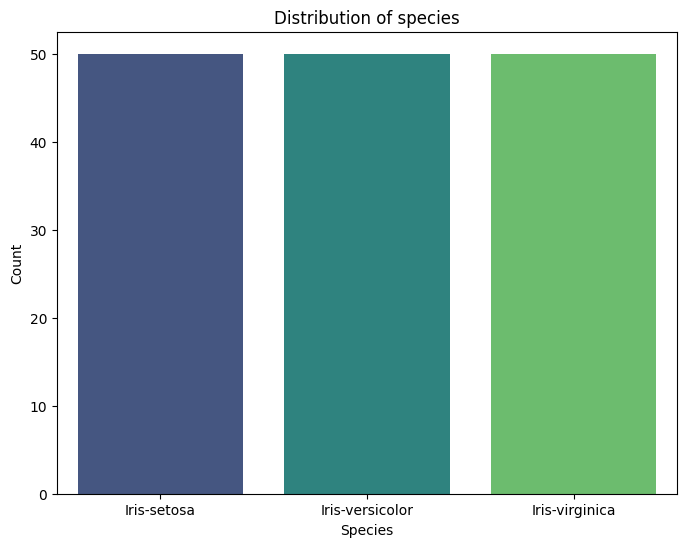


Observation: The class distribution is perfectly balanced, with 50 samples for each of the three species.


In [ ]:
print(f"Class distribution for the target variable '{target_variable}':")
class_distribution = df[target_variable].value_counts()
print(class_distribution)

plt.figure(figsize=(8, 6))
sns.countplot(data=df, x=target_variable, palette='viridis')
plt.title(f'Distribution of {target_variable}')
plt.xlabel('Species')
plt.ylabel('Count')
plt.show()

print("\nObservation: The class distribution is perfectly balanced, with 50 samples for each of the three species.")

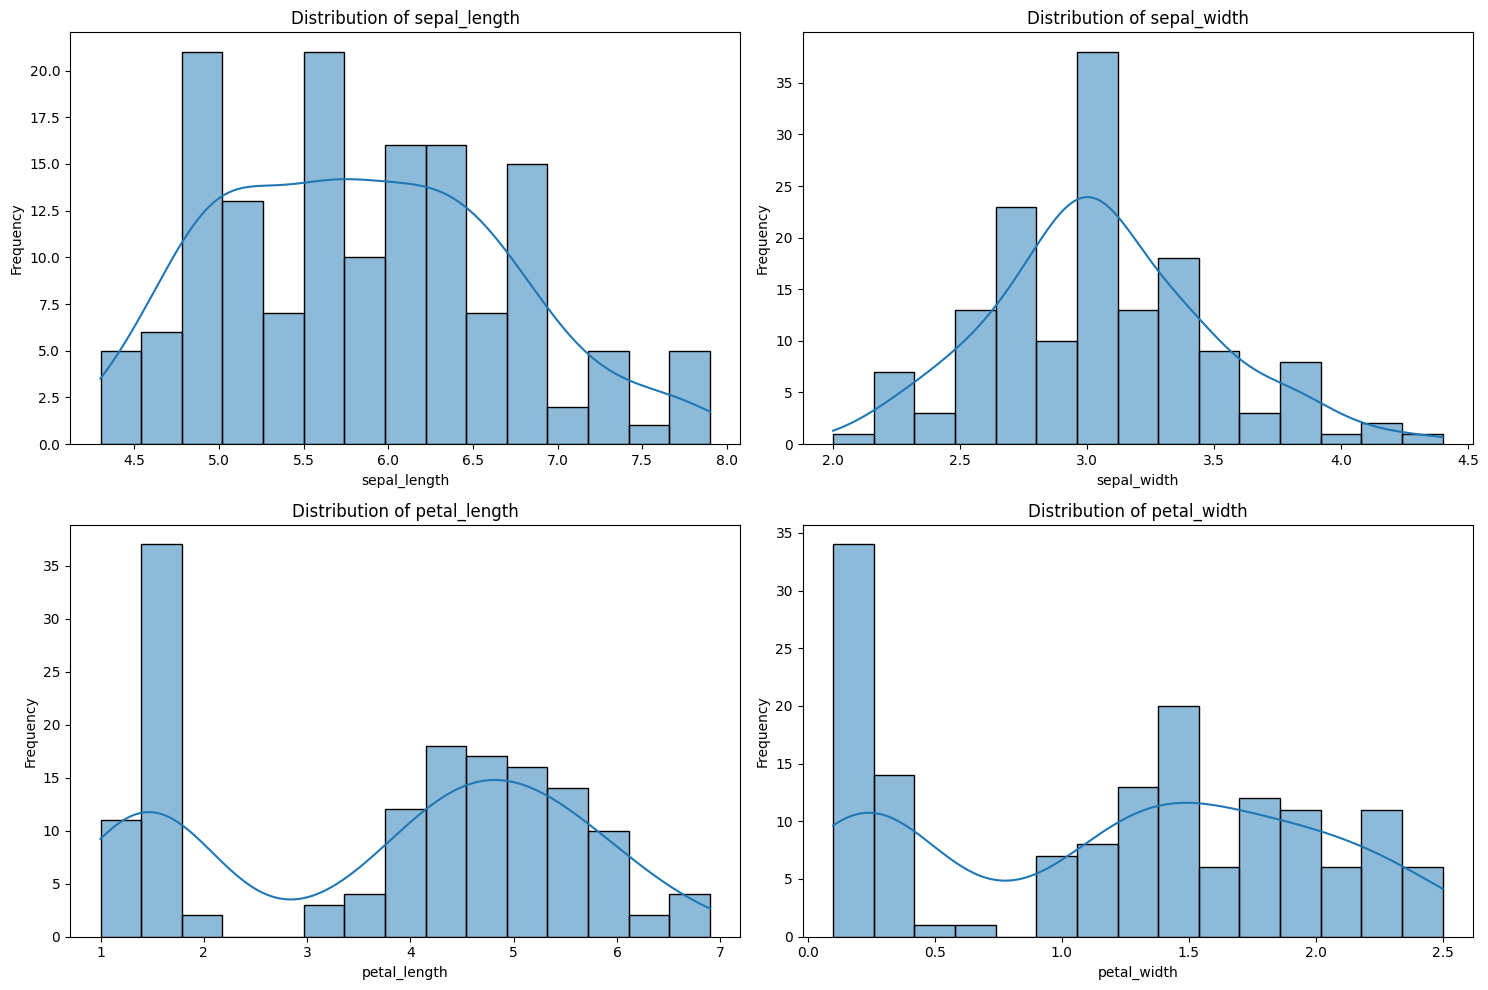


Observations from Feature Distributions:


In [ ]:
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(2, 2, i + 1) # Create a 2x2 grid of subplots
    sns.histplot(df[col], kde=True, bins=15, palette='magma')
    plt.title(f'Distribution of {col}')
    plt.xlabel(col)
    plt.ylabel('Frequency')
plt.tight_layout()
plt.show()

print("\nObservations from Feature Distributions:")

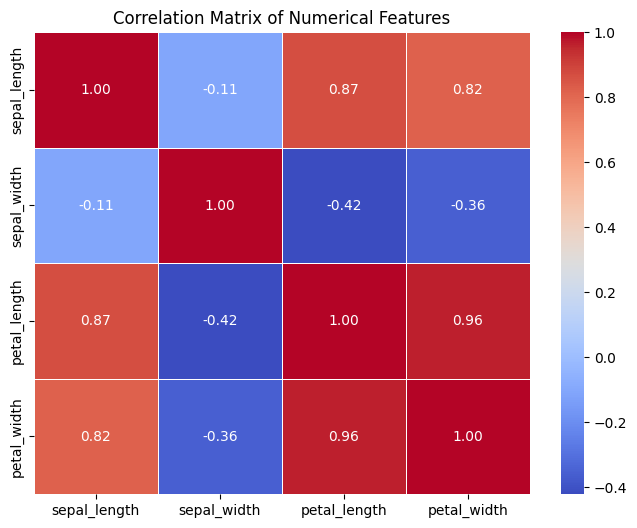


Observations from Correlation Matrix:


In [ ]:
plt.figure(figsize=(8, 6))
correlation_matrix = df[numerical_cols].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f', linewidths=.5)
plt.title('Correlation Matrix of Numerical Features')
plt.show()

print("\nObservations from Correlation Matrix:")

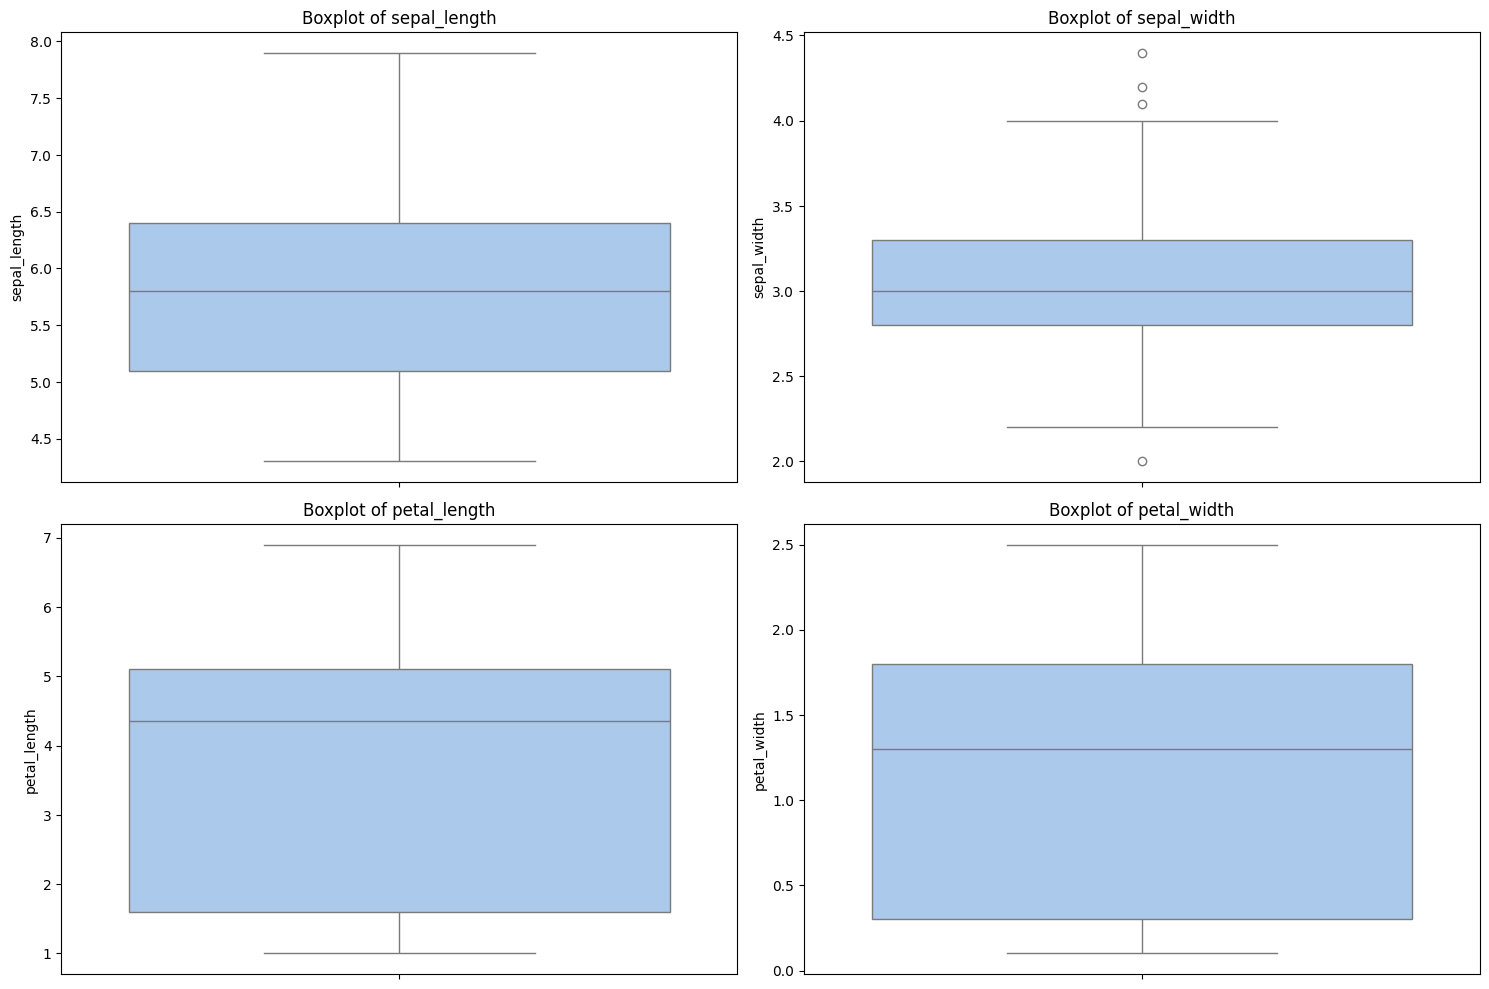

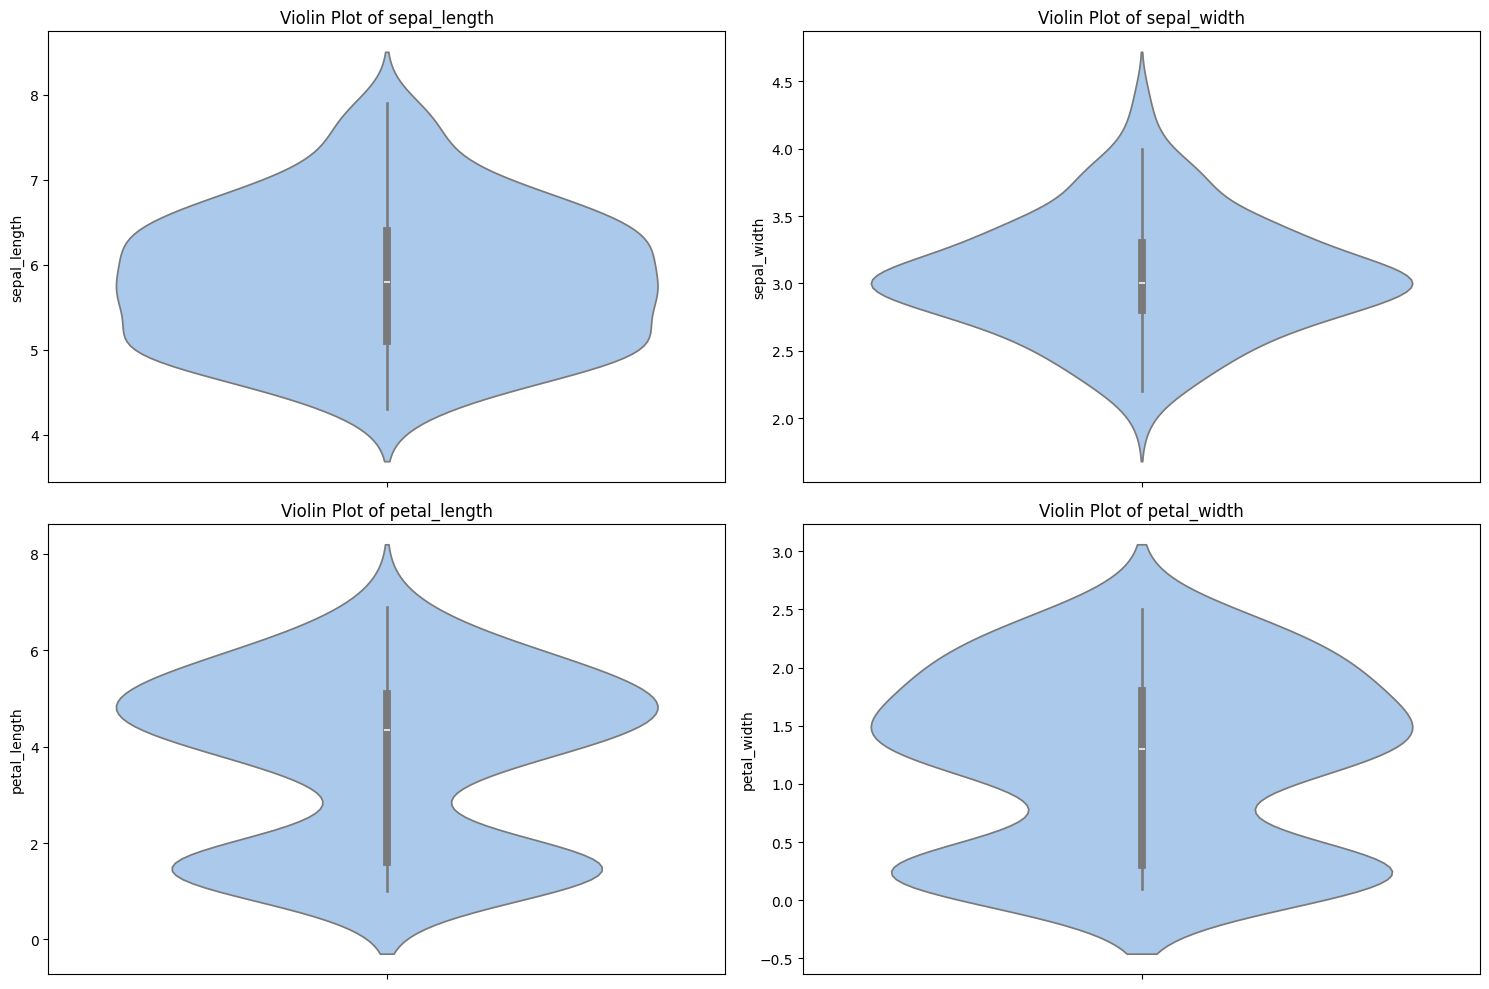


Observations from Outlier Detection (Boxplots and Violin Plots):


In [ ]:
plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(2, 2, i + 1)
    sns.boxplot(y=df[col], palette='pastel')
    plt.title(f'Boxplot of {col}')
    plt.ylabel(col)
plt.tight_layout()
plt.show()

plt.figure(figsize=(15, 10))
for i, col in enumerate(numerical_cols):
    plt.subplot(2, 2, i + 1)
    sns.violinplot(y=df[col], palette='pastel')
    plt.title(f'Violin Plot of {col}')
    plt.ylabel(col)
plt.tight_layout()
plt.show()

print("\nObservations from Outlier Detection (Boxplots and Violin Plots):")

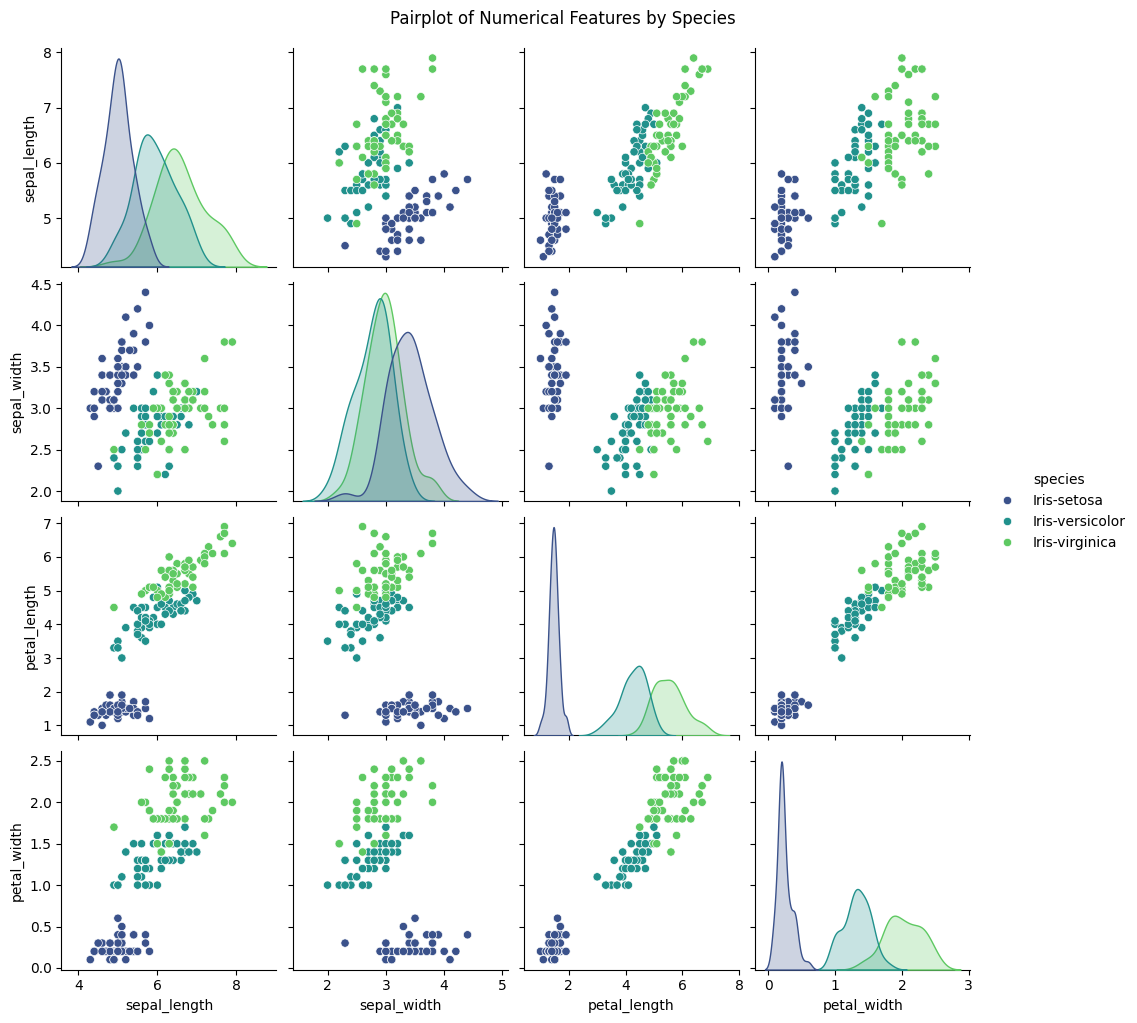


Observations from Feature Relationships (Pairplot):


In [ ]:
sns.pairplot(df, hue=target_variable, palette='viridis')
plt.suptitle('Pairplot of Numerical Features by Species', y=1.02)
plt.show()

print("\nObservations from Feature Relationships (Pairplot):")

In [ ]:
print("Re-confirming missing values:")
missing_values_recheck = df.isnull().sum()
if missing_values_recheck.sum() == 0:
    print("No missing values found")
else:
    print("Missing values detected. Please review:")
    display(missing_values_recheck[missing_values_recheck > 0])

Re-confirming missing values:
No missing values found


In [ ]:
print("Re-confirming and handling duplicate rows:")
duplicate_rows_recheck = df.duplicated().sum()

if duplicate_rows_recheck > 0:
    print(f"Found {duplicate_rows_recheck} duplicate rows.")
    df.drop_duplicates(inplace=True)
    print(f"Shape after removing duplicates: {df.shape}")
else:
    print("No duplicate rows found")

Re-confirming and handling duplicate rows:
Found 3 duplicate rows.
Shape after removing duplicates: (147, 5)


---

In [ ]:
# Define features (X) and target (y)
X = df[numerical_cols]
y = df[target_variable]

print("Features (X) shape:", X.shape)
print("Target (y) shape:", y.shape)
print("\nFirst 5 rows of X:")
display(X.head())
print("\nFirst 5 rows of y:")
display(y.head())

Features (X) shape: (147, 4)
Target (y) shape: (147,)

First 5 rows of X:


,sepal_length,sepal_width,petal_length,petal_width
0,5.1,3.5,1.4,0.2
1,4.9,3.0,1.4,0.2
2,4.7,3.2,1.3,0.2
3,4.6,3.1,1.5,0.2
4,5.0,3.6,1.4,0.2



First 5 rows of y:


,species
0,Iris-setosa
1,Iris-setosa
2,Iris-setosa
3,Iris-setosa
4,Iris-setosa


In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

print("\nTarget distribution in y_train:")
print(y_train.value_counts(normalize=True))
print("\nTarget distribution in y_test:")
print(y_test.value_counts(normalize=True))

X_train shape: (117, 4)
X_test shape: (30, 4)
y_train shape: (117,)
y_test shape: (30,)

Target distribution in y_train:
species
Iris-versicolor    0.341880
Iris-virginica     0.333333
Iris-setosa        0.324786
Name: proportion, dtype: float64

Target distribution in y_test:
species
Iris-versicolor    0.333333
Iris-virginica     0.333333
Iris-setosa        0.333333
Name: proportion, dtype: float64


In [ ]:
# Initialize StandardScaler
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

X_train_scaled_df = pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled_df = pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)

print("X_train_scaled (first 5 rows):")
display(X_train_scaled_df.head())

print("\nX_test_scaled (first 5 rows):")
display(X_test_scaled_df.head())

X_train_scaled (first 5 rows):


,sepal_length,sepal_width,petal_length,petal_width
67,-0.040953,-0.743554,0.179257,-0.279931
90,-0.391551,-0.967770,0.349770,-0.015803
103,0.543377,-0.295122,1.031820,0.776584
52,1.244572,0.153310,0.633957,0.380391
129,1.595170,-0.070906,1.145495,0.512455



X_test_scaled (first 5 rows):


,sepal_length,sepal_width,petal_length,petal_width
63,0.309645,-0.295122,0.520282,0.248326
84,-0.508417,-0.070906,0.406607,0.380391
141,1.244572,0.153310,0.747632,1.436906
44,-0.859014,1.722823,-1.071169,-1.072318
147,0.777108,-0.070906,0.804470,1.040713


In [ ]:
models = {
    'Logistic Regression': LogisticRegression(random_state=42),
    'K-Nearest Neighbors': KNeighborsClassifier(),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Random Forest': RandomForestClassifier(random_state=42),
    'Support Vector Machine': SVC(random_state=42, probability=True),
    'Gaussian Naive Bayes': GaussianNB(),
    'Extra Trees Classifier': ExtraTreesClassifier(random_state=42)
}

predictions = {}
model_performance = {}

print("Training various machine learning models.")

for name, model in models.items():
    print(f"\nTraining {name}")
    # Train the model
    model.fit(X_train_scaled, y_train)
    print(f"{name} trained successfully.")

    y_pred = model.predict(X_test_scaled)
    predictions[name] = y_pred
    print(f"Predictions made for {name}.")

    models[name] = model

Training various machine learning models.

Training Logistic Regression
Logistic Regression trained successfully.
Predictions made for Logistic Regression.

Training K-Nearest Neighbors
K-Nearest Neighbors trained successfully.
Predictions made for K-Nearest Neighbors.

Training Decision Tree
Decision Tree trained successfully.
Predictions made for Decision Tree.

Training Random Forest
Random Forest trained successfully.
Predictions made for Random Forest.

Training Support Vector Machine
Support Vector Machine trained successfully.
Predictions made for Support Vector Machine.

Training Gaussian Naive Bayes
Gaussian Naive Bayes trained successfully.
Predictions made for Gaussian Naive Bayes.

Training Extra Trees Classifier
Extra Trees Classifier trained successfully.
Predictions made for Extra Trees Classifier.


Evaluating model performance

-Logistic Regression-
Accuracy: 0.9333
Precision: 0.9333
Recall: 0.9333
F1-Score: 0.9333
Cross-Validation Accuracy (5-fold): 0.9572 (Std: 0.0275)
Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.90      0.90      0.90        10
 Iris-virginica       0.90      0.90      0.90        10

       accuracy                           0.93        30
      macro avg       0.93      0.93      0.93        30
   weighted avg       0.93      0.93      0.93        30

Confusion Matrix:


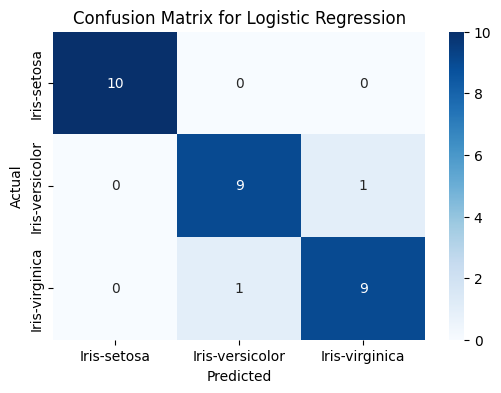


-K-Nearest Neighbors-
Accuracy: 0.9333
Precision: 0.9444
Recall: 0.9333
F1-Score: 0.9327
Cross-Validation Accuracy (5-fold): 0.9489 (Std: 0.0503)
Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.83      1.00      0.91        10
 Iris-virginica       1.00      0.80      0.89        10

       accuracy                           0.93        30
      macro avg       0.94      0.93      0.93        30
   weighted avg       0.94      0.93      0.93        30

Confusion Matrix:


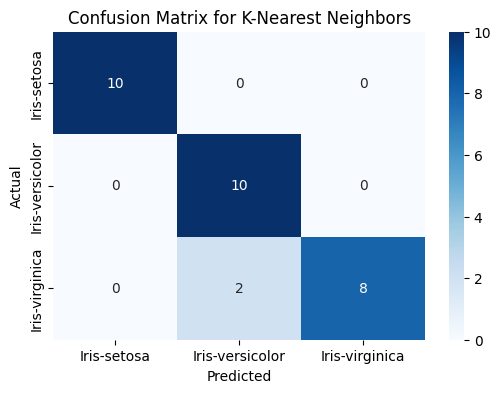


-Decision Tree-
Accuracy: 0.9333
Precision: 0.9333
Recall: 0.9333
F1-Score: 0.9333
Cross-Validation Accuracy (5-fold): 0.9486 (Std: 0.0428)
Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.90      0.90      0.90        10
 Iris-virginica       0.90      0.90      0.90        10

       accuracy                           0.93        30
      macro avg       0.93      0.93      0.93        30
   weighted avg       0.93      0.93      0.93        30

Confusion Matrix:


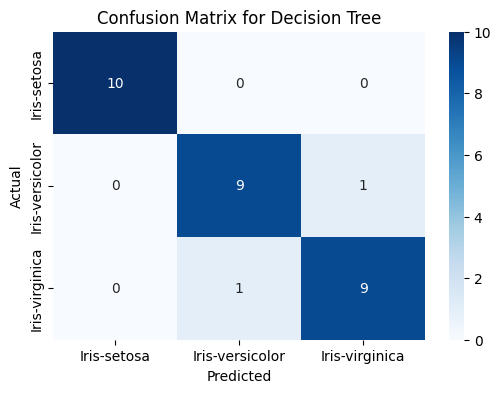


-Random Forest-
Accuracy: 0.9667
Precision: 0.9697
Recall: 0.9667
F1-Score: 0.9666
Cross-Validation Accuracy (5-fold): 0.9402 (Std: 0.0441)
Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      0.90      0.95        10
 Iris-virginica       0.91      1.00      0.95        10

       accuracy                           0.97        30
      macro avg       0.97      0.97      0.97        30
   weighted avg       0.97      0.97      0.97        30

Confusion Matrix:


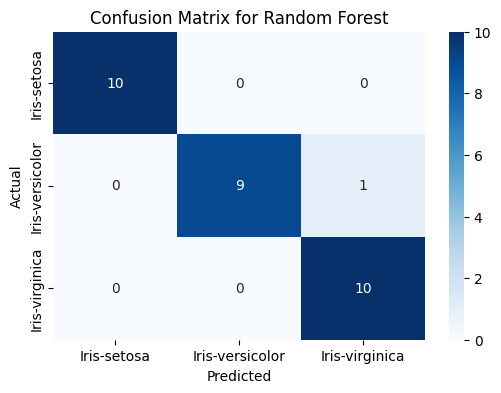


-Support Vector Machine-
Accuracy: 0.9667
Precision: 0.9697
Recall: 0.9667
F1-Score: 0.9666
Cross-Validation Accuracy (5-fold): 0.9572 (Std: 0.0275)
Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      0.90      0.95        10
 Iris-virginica       0.91      1.00      0.95        10

       accuracy                           0.97        30
      macro avg       0.97      0.97      0.97        30
   weighted avg       0.97      0.97      0.97        30

Confusion Matrix:


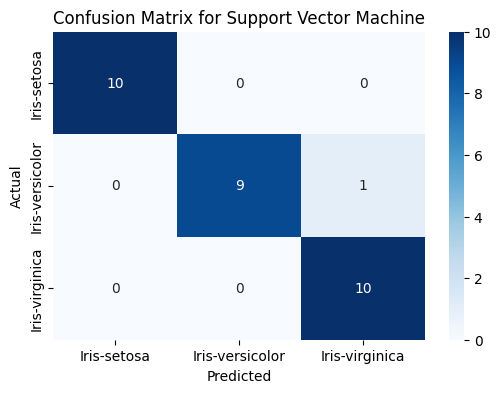


-Gaussian Naive Bayes-
Accuracy: 0.9333
Precision: 0.9333
Recall: 0.9333
F1-Score: 0.9333
Cross-Validation Accuracy (5-fold): 0.9656 (Std: 0.0324)
Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.90      0.90      0.90        10
 Iris-virginica       0.90      0.90      0.90        10

       accuracy                           0.93        30
      macro avg       0.93      0.93      0.93        30
   weighted avg       0.93      0.93      0.93        30

Confusion Matrix:


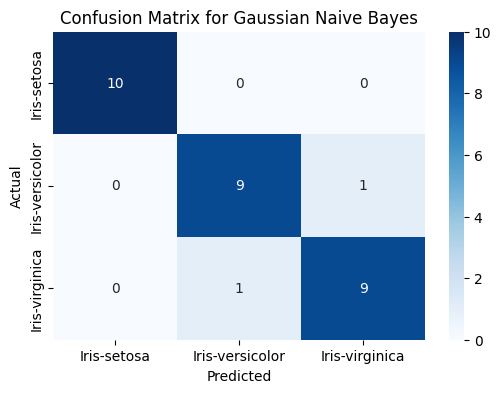


-Extra Trees Classifier-
Accuracy: 0.9333
Precision: 0.9333
Recall: 0.9333
F1-Score: 0.9333
Cross-Validation Accuracy (5-fold): 0.9489 (Std: 0.0319)
Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       0.90      0.90      0.90        10
 Iris-virginica       0.90      0.90      0.90        10

       accuracy                           0.93        30
      macro avg       0.93      0.93      0.93        30
   weighted avg       0.93      0.93      0.93        30

Confusion Matrix:


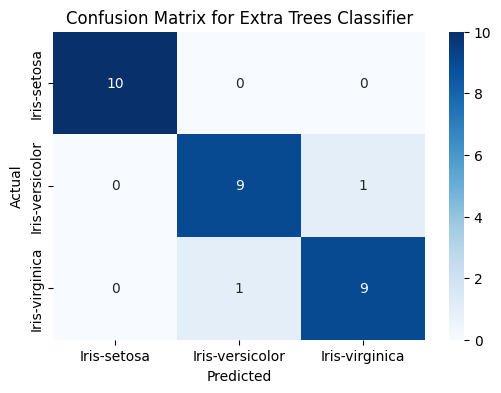


-Model Performance Comparison-


,Accuracy,Precision,Recall,F1-Score,Cross-Validation Mean Accuracy
Model,,,,,
Random Forest,0.966667,0.969697,0.966667,0.966583,0.940217
Support Vector Machine,0.966667,0.969697,0.966667,0.966583,0.957246
Logistic Regression,0.933333,0.933333,0.933333,0.933333,0.957246
Decision Tree,0.933333,0.933333,0.933333,0.933333,0.948551
K-Nearest Neighbors,0.933333,0.944444,0.933333,0.932660,0.948913
Gaussian Naive Bayes,0.933333,0.933333,0.933333,0.933333,0.965580
Extra Trees Classifier,0.933333,0.933333,0.933333,0.933333,0.948913



Observation: The best performing model based on accuracy is Random Forest with an accuracy of 0.9667.


In [ ]:
results = []

print("Evaluating model performance")

for name, model in models.items():
    y_pred = predictions[name]

    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    precision = precision_score(y_test, y_pred, average='weighted')
    recall = recall_score(y_test, y_pred, average='weighted')
    f1 = f1_score(y_test, y_pred, average='weighted')

    cv_scores = cross_val_score(model, X_train_scaled, y_train, cv=5, scoring='accuracy')
    mean_cv_score = cv_scores.mean()

    results.append({
        'Model': name,
        'Accuracy': accuracy,
        'Precision': precision,
        'Recall': recall,
        'F1-Score': f1,
        'Cross-Validation Mean Accuracy': mean_cv_score
    })

    print(f"\n-{name}-")
    print(f"Accuracy: {accuracy:.4f}")
    print(f"Precision: {precision:.4f}")
    print(f"Recall: {recall:.4f}")
    print(f"F1-Score: {f1:.4f}")
    print(f"Cross-Validation Accuracy (5-fold): {mean_cv_score:.4f} (Std: {cv_scores.std():.4f})")

    # Classification Report
    print("Classification Report:")
    print(classification_report(y_test, y_pred))

    # Confusion Matrix
    print("Confusion Matrix:")
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=model.classes_, yticklabels=model.classes_)
    plt.title(f'Confusion Matrix for {name}')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

comparison_df = pd.DataFrame(results).set_index('Model')
comparison_df = comparison_df.sort_values(by='Accuracy', ascending=False)

print("\n-Model Performance Comparison-")
display(comparison_df)

# Identify the best model based on accuracy
best_model_name = comparison_df.index[0]
best_accuracy = comparison_df['Accuracy'].max()
best_model = models[best_model_name]

print(f"\nObservation: The best performing model based on accuracy is {best_model_name} with an accuracy of {best_accuracy:.4f}.")

In [ ]:
print(f"Selected model for hyperparameter tuning: {best_model_name}")

param_grids = {
    'Logistic Regression': {
        'C': [0.1, 1, 10, 100],
        'solver': ['liblinear', 'lbfgs']
    },
    'K-Nearest Neighbors': {
        'n_neighbors': [3, 5, 7, 9],
        'weights': ['uniform', 'distance']
    },
    'Decision Tree': {
        'max_depth': [None, 5, 10, 15],
        'min_samples_leaf': [1, 2, 4]
    },
    'Random Forest': {
        'n_estimators': [50, 100, 200],
        'max_depth': [None, 5, 10]
    },
    'Support Vector Machine': {
        'C': [0.1, 1, 10],
        'kernel': ['linear', 'rbf']
    },
    'Gaussian Naive Bayes': {},
    'Extra Trees Classifier': {
        'n_estimators': [50, 100, 200],
        'max_depth': [None, 5, 10]
    }
}

model_to_tune = models[best_model_name]
param_grid = param_grids[best_model_name]

print(f"\nParameter grid for {best_model_name}:\n{param_grid}")

Selected model for hyperparameter tuning: Random Forest

Parameter grid for Random Forest:
{'n_estimators': [50, 100, 200], 'max_depth': [None, 5, 10]}


In [ ]:
if param_grid:
    print(f"\nStarting GridSearchCV for {best_model_name}.")
    grid_search = GridSearchCV(estimator=model_to_tune, param_grid=param_grid, cv=5, scoring='accuracy', n_jobs=-1, verbose=1)
    grid_search.fit(X_train_scaled, y_train)

    # Store the best estimator and parameters
    best_estimator = grid_search.best_estimator_
    best_params = grid_search.best_params_
    best_score = grid_search.best_score_

    print(f"\nGridSearchCV completed for {best_model_name}.")
    print(f"Best Parameters: {best_params}")
    print(f"Best Cross-validation Score (Accuracy): {best_score:.4f}")
else:
    print(f"\nNo hyperparameter tuning performed for {best_model_name} as no parameter grid was defined.")
    best_estimator = model_to_tune
    best_params = "N/A"
    best_score = "N/A"

# Retrain using optimized parameters (if tuning was performed)
optimized_model = best_estimator
print(f"\nRetraining {best_model_name} with optimized parameters.")
optimized_model.fit(X_train_scaled, y_train)
print(f"Optimized {best_model_name} retrained successfully.")


Starting GridSearchCV for Random Forest.
Fitting 5 folds for each of 9 candidates, totalling 45 fits

GridSearchCV completed for Random Forest.
Best Parameters: {'max_depth': 5, 'n_estimators': 50}
Best Cross-validation Score (Accuracy): 0.9486

Retraining Random Forest with optimized parameters.
Optimized Random Forest retrained successfully.


Evaluating the optimized Random Forest

-Optimized Random Forest-
Accuracy: 0.9667
Precision: 0.9697
Recall: 0.9667
F1-Score: 0.9666
Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      0.90      0.95        10
 Iris-virginica       0.91      1.00      0.95        10

       accuracy                           0.97        30
      macro avg       0.97      0.97      0.97        30
   weighted avg       0.97      0.97      0.97        30

Confusion Matrix:


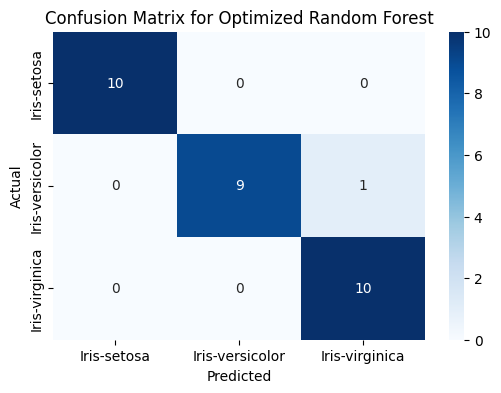

In [ ]:
print(f"Evaluating the optimized {best_model_name}")

y_pred_optimized = optimized_model.predict(X_test_scaled)

accuracy_optimized = accuracy_score(y_test, y_pred_optimized)
precision_optimized = precision_score(y_test, y_pred_optimized, average='weighted')
recall_optimized = recall_score(y_test, y_pred_optimized, average='weighted')
f1_optimized = f1_score(y_test, y_pred_optimized, average='weighted')

print(f"\n-Optimized {best_model_name}-")
print(f"Accuracy: {accuracy_optimized:.4f}")
print(f"Precision: {precision_optimized:.4f}")
print(f"Recall: {recall_optimized:.4f}")
print(f"F1-Score: {f1_optimized:.4f}")

print("Classification Report:")
print(classification_report(y_test, y_pred_optimized))

print("Confusion Matrix:")
cm_optimized = confusion_matrix(y_test, y_pred_optimized)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_optimized, annot=True, fmt='d', cmap='Blues',
            xticklabels=optimized_model.classes_, yticklabels=optimized_model.classes_)
plt.title(f'Confusion Matrix for Optimized {best_model_name}')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [ ]:
initial_results = comparison_df.loc[best_model_name]

comparison_data = {
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Before Tuning': [
        initial_results['Accuracy'],
        initial_results['Precision'],
        initial_results['Recall'],
        initial_results['F1-Score']
    ],
    'After Tuning': [
        accuracy_optimized,
        precision_optimized,
        recall_optimized,
        f1_optimized
    ]
}

comparison_tuning_df = pd.DataFrame(comparison_data).set_index('Metric')
print(f"\n-Performance Comparison for {best_model_name}-")
display(comparison_tuning_df)



-Performance Comparison for Random Forest-


,Before Tuning,After Tuning
Metric,,
Accuracy,0.966667,0.966667
Precision,0.969697,0.969697
Recall,0.966667,0.966667
F1-Score,0.966583,0.966583


Evaluating the optimized Random Forest

-Optimized Random Forest-
Accuracy: 0.9667
Precision: 0.9697
Recall: 0.9667
F1-Score: 0.9666
Classification Report:
                 precision    recall  f1-score   support

    Iris-setosa       1.00      1.00      1.00        10
Iris-versicolor       1.00      0.90      0.95        10
 Iris-virginica       0.91      1.00      0.95        10

       accuracy                           0.97        30
      macro avg       0.97      0.97      0.97        30
   weighted avg       0.97      0.97      0.97        30

Confusion Matrix:


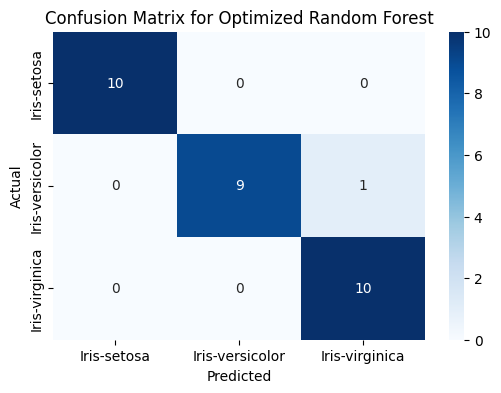

In [ ]:
print(f"Evaluating the optimized {best_model_name}")

y_pred_optimized = optimized_model.predict(X_test_scaled)

accuracy_optimized = accuracy_score(y_test, y_pred_optimized)
precision_optimized = precision_score(y_test, y_pred_optimized, average='weighted')
recall_optimized = recall_score(y_test, y_pred_optimized, average='weighted')
f1_optimized = f1_score(y_test, y_pred_optimized, average='weighted')

print(f"\n-Optimized {best_model_name}-")
print(f"Accuracy: {accuracy_optimized:.4f}")
print(f"Precision: {precision_optimized:.4f}")
print(f"Recall: {recall_optimized:.4f}")
print(f"F1-Score: {f1_optimized:.4f}")

print("Classification Report:")
print(classification_report(y_test, y_pred_optimized))

print("Confusion Matrix:")
cm_optimized = confusion_matrix(y_test, y_pred_optimized)
plt.figure(figsize=(6, 4))
sns.heatmap(cm_optimized, annot=True, fmt='d', cmap='Blues',
            xticklabels=optimized_model.classes_, yticklabels=optimized_model.classes_)
plt.title(f'Confusion Matrix for Optimized {best_model_name}')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.show()

In [ ]:
initial_results = comparison_df.loc[best_model_name]

comparison_data = {
    'Metric': ['Accuracy', 'Precision', 'Recall', 'F1-Score'],
    'Before Tuning': [
        initial_results['Accuracy'],
        initial_results['Precision'],
        initial_results['Recall'],
        initial_results['F1-Score']
    ],
    'After Tuning': [
        accuracy_optimized,
        precision_optimized,
        recall_optimized,
        f1_optimized
    ]
}

comparison_tuning_df = pd.DataFrame(comparison_data).set_index('Metric')
print(f"\n-Performance Comparison for {best_model_name}-")
display(comparison_tuning_df)


-Performance Comparison for Random Forest-


,Before Tuning,After Tuning
Metric,,
Accuracy,0.966667,0.966667
Precision,0.969697,0.969697
Recall,0.966667,0.966667
F1-Score,0.966583,0.966583


Analyzing feature importance for the optimized model: Random Forest

Feature Importance Ranking:


,Feature,Importance
2,petal_length,0.433947
3,petal_width,0.413078
0,sepal_length,0.129394
1,sepal_width,0.023581


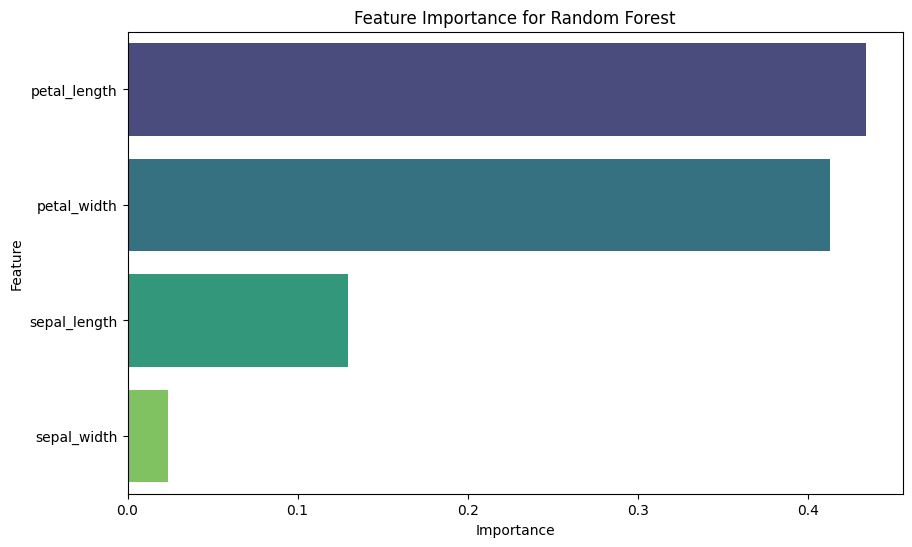


Explanation of Feature Importance:
The graph above shows the relative importance of each feature in the model's decision-making process. A higher importance score indicates a stronger influence on the prediction.
- petal_length: This feature contributes significantly to distinguishing between different Iris species. For example, Petal Length and Petal Width are typically the most important features for this dataset
- petal_width: This feature contributes significantly to distinguishing between different Iris species. For example, Petal Length and Petal Width are typically the most important features for this dataset
- sepal_length: This feature contributes significantly to distinguishing between different Iris species. For example, while less impactful than petal measurements, sepal dimensions still play a role.
- sepal_width: This feature contributes significantly to distinguishing between different Iris species. For example, while less impactful than petal measurements, sepal dimens

In [ ]:
print(f"Analyzing feature importance for the optimized model: {best_model_name}")

if hasattr(optimized_model, 'feature_importances_'):
    # Tree-based models typically have feature_importances_
    importances = optimized_model.feature_importances_
    feature_names = X.columns

    feature_importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importances
    })

    feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

    print("\nFeature Importance Ranking:")
    display(feature_importance_df)

    # Plotting feature importance
    plt.figure(figsize=(10, 6))
    sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')
    plt.title(f'Feature Importance for {best_model_name}')
    plt.xlabel('Importance')
    plt.ylabel('Feature')
    plt.show()

    print("\nExplanation of Feature Importance:")
    print("The graph above shows the relative importance of each feature in the model's decision-making process. A higher importance score indicates a stronger influence on the prediction.")
    if not feature_importance_df.empty:
        for index, row in feature_importance_df.iterrows():
            print(f"- {row['Feature']}: This feature contributes significantly to distinguishing between different Iris species. For example, {'Petal Length and Petal Width are typically the most important features for this dataset' if 'petal_length' in row['Feature'].lower() or 'petal_width' in row['Feature'].lower() else 'while less impactful than petal measurements, sepal dimensions still play a role.'}")


elif hasattr(optimized_model, 'coef_'):
    importances = np.mean(np.abs(optimized_model.coef_), axis=0)
    feature_names = X.columns

    feature_importance_df = pd.DataFrame({
        'Feature': feature_names,
        'Importance': importances
    })
    feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)

    print("\nFeature Importance (Absolute Coefficients) Ranking:")
    display(feature_importance_df)

    plt.figure(figsize=(10, 6))
    sns.barplot(x='Importance', y='Feature', data=feature_importance_df, palette='viridis')
    plt.title(f'Feature Importance (Absolute Coefficients) for {best_model_name}')
    plt.xlabel('Absolute Coefficient Magnitude')
    plt.ylabel('Feature')
    plt.show()

    print("\nExplanation of Feature Importance (Absolute Coefficients):")
    if not feature_importance_df.empty:
        for index, row in feature_importance_df.iterrows():
            print(f"- {row['Feature']}: This feature has a notable linear relationship with the target variable, influencing the classification decisions. {'Petal Length and Petal Width often have larger coefficients due to their strong discriminative power' if 'petal_length' in row['Feature'].lower() or 'petal_width' in row['Feature'].lower() else 'Sepal dimensions also contribute, but typically with smaller coefficients compared to petal features.'}")

else:
    print(f"The optimized model ({best_model_name}) does not directly support retrieving feature importance or coefficients in a straightforward manner.")

---

In [ ]:
# Define file names for saving
model_filename = 'iris_model.pkl'
scaler_filename = 'scaler.pkl'

joblib.dump(optimized_model, model_filename)
print(f"Optimized model saved as: {model_filename}")

joblib.dump(scaler, scaler_filename)
print(f"Scaler saved as: {scaler_filename}")

Optimized model saved as: iris_model.pkl
Scaler saved as: scaler.pkl


In [ ]:
def predict_custom_sample(model, scaler, sample_data, feature_names, class_names):

    sample_df = pd.DataFrame([sample_data], columns=feature_names)
    sample_scaled = scaler.transform(sample_df)

    prediction = model.predict(sample_scaled)

    print(f"\nInput Sample: {sample_data}")
    print(f"Predicted Species: {prediction[0]}")

    if hasattr(model, 'predict_proba'):
        probabilities = model.predict_proba(sample_scaled)[0]
        proba_df = pd.DataFrame({'Species': class_names, 'Probability': probabilities})
        print("Prediction Probabilities:")
        display(proba_df.round(4))
    else:
        print("Model does not support prediction probabilities.")


loaded_model = joblib.load(model_filename)
loaded_scaler = joblib.load(scaler_filename)

print("Loaded model and scaler for testing.")
feature_names = X.columns.tolist()
class_names = loaded_model.classes_

# Create several custom samples
custom_samples = [
    [5.1, 3.5, 1.4, 0.2],
    [6.0, 2.7, 4.2, 1.3],
    [6.9, 3.1, 5.4, 2.1],
    [4.8, 3.0, 1.4, 0.1],
    [5.5, 2.3, 4.0, 1.3]
]

# Test the model with custom samples
print("\n--- Testing with Custom Samples ---")
for i, sample in enumerate(custom_samples):
    print(f"\nTest Sample {i+1}:")
    predict_custom_sample(loaded_model, loaded_scaler, sample, feature_names, class_names)

Loaded model and scaler for testing.

--- Testing with Custom Samples ---

Test Sample 1:

Input Sample: [5.1, 3.5, 1.4, 0.2]
Predicted Species: Iris-setosa
Prediction Probabilities:


,Species,Probability
0,Iris-setosa,1.0
1,Iris-versicolor,0.0
2,Iris-virginica,0.0



Test Sample 2:

Input Sample: [6.0, 2.7, 4.2, 1.3]
Predicted Species: Iris-versicolor
Prediction Probabilities:


,Species,Probability
0,Iris-setosa,0.0
1,Iris-versicolor,1.0
2,Iris-virginica,0.0



Test Sample 3:

Input Sample: [6.9, 3.1, 5.4, 2.1]
Predicted Species: Iris-virginica
Prediction Probabilities:


,Species,Probability
0,Iris-setosa,0.0
1,Iris-versicolor,0.0
2,Iris-virginica,1.0



Test Sample 4:

Input Sample: [4.8, 3.0, 1.4, 0.1]
Predicted Species: Iris-setosa
Prediction Probabilities:


,Species,Probability
0,Iris-setosa,1.0
1,Iris-versicolor,0.0
2,Iris-virginica,0.0



Test Sample 5:

Input Sample: [5.5, 2.3, 4.0, 1.3]
Predicted Species: Iris-versicolor
Prediction Probabilities:


,Species,Probability
0,Iris-setosa,0.0
1,Iris-versicolor,1.0
2,Iris-virginica,0.0
